In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
df = pd.read_csv('crop_recommendation.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [68]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [69]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [70]:
df['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

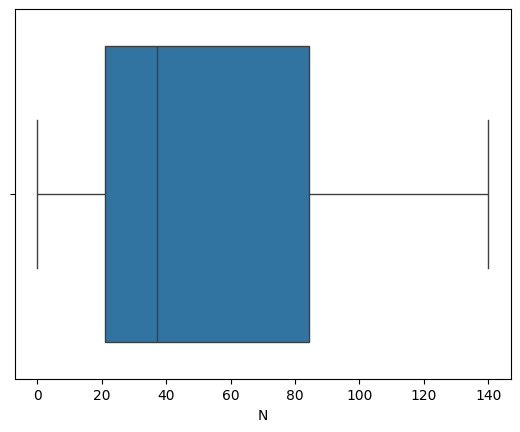

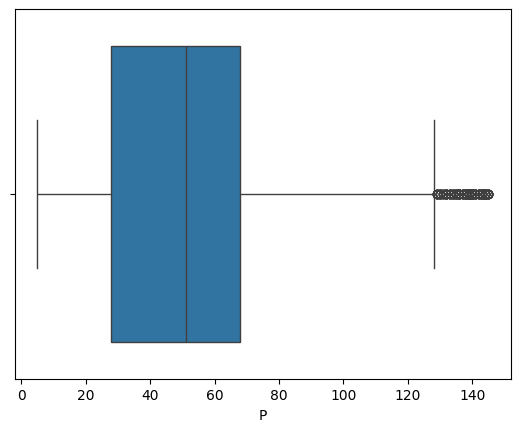

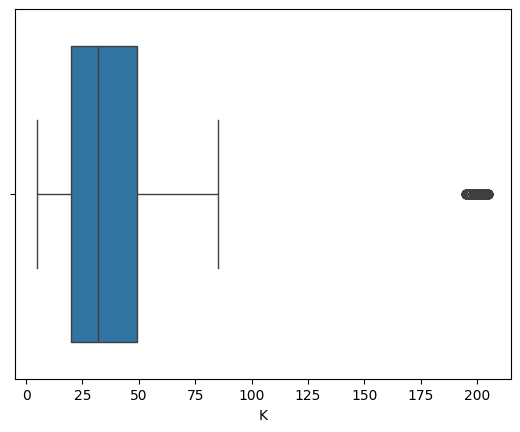

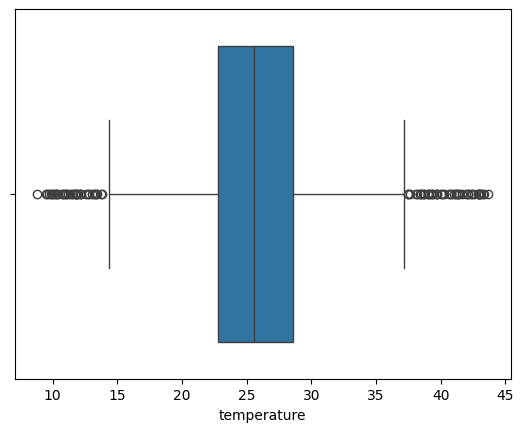

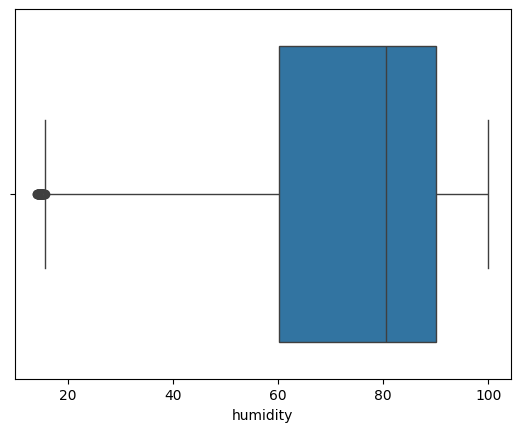

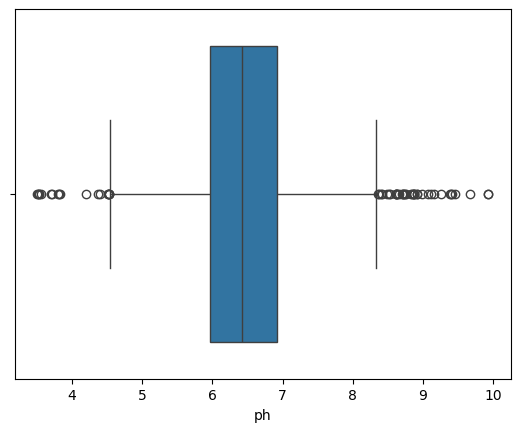

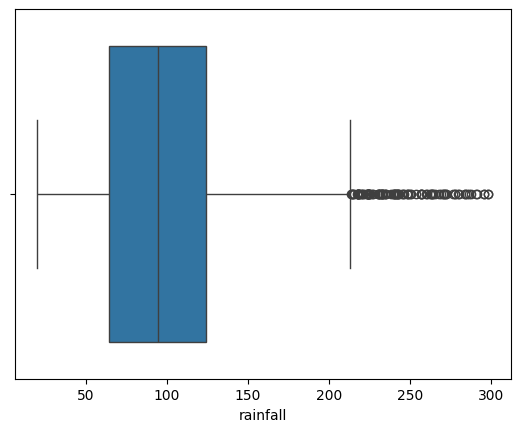

In [71]:
for col in df.select_dtypes(include='number').columns:
  sns.boxplot(x=df[col])

  # LQ = df[col].quantile(0.25)
  # UQ = df[col].quantile(0.75)
  # IQR = UQ - LQ
  # lower_bound = LQ - 1.5 * IQR
  # upper_bound = UQ + 1.5 * IQR

  # df = df[(df[col] <= upper_bound) & (df[col] >= lower_bound)]

  plt.show()

In [72]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

def train_test_splitter(data, target_column, test_size=0.2, random_state=42):
  X = data.drop(columns=[target_column])
  y = data[target_column]
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
  return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_splitter(df, 'label')

models = {
  'Decision Tree': DecisionTreeClassifier(),
  'Random Forest': RandomForestClassifier()
}

results = {}
for model_name, model in models.items():
  print(model_name)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  results[model_name] = accuracy

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.fit_transform(y_test)
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=400)
lr.fit(X_train_scaled, y_train_encoded)
y_pred_lr = lr.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test_encoded, y_pred_lr)
results['Logistic Regression'] = accuracy_lr

# XGBoost
xb = xgb.XGBClassifier(use_label_encoder=True, eval_metric='mlogloss')
xb.fit(X_train_scaled, y_train_encoded)
y_pred_xb = xb.predict(X_test_scaled)
accuracy_xb = accuracy_score(y_test_encoded, y_pred_xb)
results['XGBoost'] = accuracy_xb

pd.DataFrame(results, index=['Accuracy']).T

Decision Tree
Random Forest


c:\Users\Dell\Desktop\sem-repos\mlFall25\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:49:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Accuracy
Decision Tree,0.986364
Random Forest,0.993182
Logistic Regression,0.963636
XGBoost,0.986364
